In [1]:
!pip install kaggle

from google.colab import files

files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
!kaggle datasets download "masoudnickparvar/brain-tumor-mri-dataset"

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 15.6MB/s]



In [4]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [5]:
import os

data_path = "/content"

for split in ["Training", "Testing"]:
  print(f"\n{split.upper()}")

  for folder in os.listdir(os.path.join(data_path, split)):
    print(f"{folder}: {len(os.listdir(os.path.join(data_path, split, folder)))}")


TRAINING
glioma: 1400
notumor: 1400
pituitary: 1400
meningioma: 1400

TESTING
glioma: 400
notumor: 400
pituitary: 400
meningioma: 400


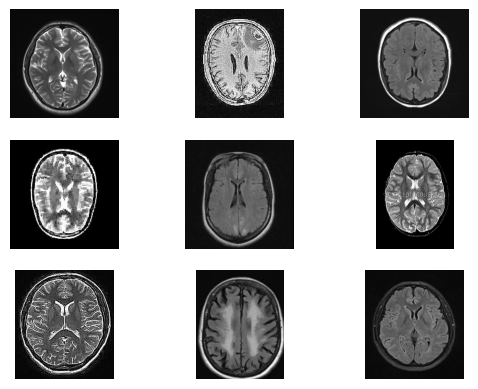

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

folder = "/content/Training/notumor"

images = random.sample(os.listdir(folder),9)

for i, image in enumerate(images):
  plt.subplot(3, 3, i+1)
  img = Image.open(os.path.join(folder, image))
  plt.subplot(3, 3, i+1)
  plt.imshow(img, cmap="gray")
  plt.axis("off")

plt.show()





In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=5, translate=(0.01, 0.01)),
    transforms.Lambda(lambda x : x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.Lambda(lambda x : x.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [8]:
from torchvision import datasets

train_data = datasets.ImageFolder(os.path.join(data_path, "Training"), transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, "Testing"), transform=test_transform)



In [9]:
print("Data set size:")
print(f"Train: {len(train_data)}")
print(f"Test: {len(test_data)}")


Data set size:
Train: 5600
Test: 1600


In [10]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [11]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):
    model.train()

    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device,
):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
            test_acc += (test_pred_class == y).sum().item() / len(test_pred)

        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
    return test_loss, test_acc




In [12]:
def train (
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device,
):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device,
        )

        if epoch % 2 == 0 :
          print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


    return results

In [13]:
from torchvision import models

model_0 = models.resnet50(weights = "DEFAULT")

for param in model_0.parameters(): param.requires_grad = False

model_0.fc = torch.nn.Linear(model_0.fc.in_features, 4)

model_0.to(device)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


In [14]:
model_0_results = train(
    model=model_0,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,
    device=device,
)

Epoch: 0 | Train loss: 0.7143 | Train acc: 0.7789 | Test loss: 0.6772 | Test acc: 0.7781
Epoch: 2 | Train loss: 0.3763 | Train acc: 0.8766 | Test loss: 0.6192 | Test acc: 0.7994
Epoch: 4 | Train loss: 0.3163 | Train acc: 0.8936 | Test loss: 0.5707 | Test acc: 0.8137
Epoch: 6 | Train loss: 0.2872 | Train acc: 0.8989 | Test loss: 0.5115 | Test acc: 0.8250
Epoch: 8 | Train loss: 0.2629 | Train acc: 0.9086 | Test loss: 0.5154 | Test acc: 0.8281
Epoch: 10 | Train loss: 0.2543 | Train acc: 0.9123 | Test loss: 0.4931 | Test acc: 0.8356
Epoch: 12 | Train loss: 0.2418 | Train acc: 0.9150 | Test loss: 0.5077 | Test acc: 0.8356
Epoch: 14 | Train loss: 0.2350 | Train acc: 0.9186 | Test loss: 0.4901 | Test acc: 0.8381


In [15]:
model_1 = models.vgg16(weights = "DEFAULT")

for param in model_1.parameters(): param.requires_grad = False

model_1.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=25088, out_features=4096, bias=True),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=0.5, inplace=False),
    torch.nn.Linear(in_features=4096, out_features=4096, bias=True),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=0.5, inplace=False),
    torch.nn.Linear(in_features=4096, out_features=4, bias=True)
)

model_1.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.0MB/s]


In [16]:
model_1_results = train(
    model=model_1,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,
    device=device,
)

Epoch: 0 | Train loss: 0.7806 | Train acc: 0.8043 | Test loss: 0.6450 | Test acc: 0.7969
Epoch: 2 | Train loss: 0.3384 | Train acc: 0.8862 | Test loss: 0.5335 | Test acc: 0.8512
Epoch: 4 | Train loss: 0.3548 | Train acc: 0.8818 | Test loss: 0.5604 | Test acc: 0.8538
Epoch: 6 | Train loss: 0.3329 | Train acc: 0.8964 | Test loss: 0.5173 | Test acc: 0.8819
Epoch: 8 | Train loss: 0.2980 | Train acc: 0.9127 | Test loss: 0.4680 | Test acc: 0.8831
Epoch: 10 | Train loss: 0.2608 | Train acc: 0.9186 | Test loss: 0.6401 | Test acc: 0.8575
Epoch: 12 | Train loss: 0.3082 | Train acc: 0.9123 | Test loss: 0.4036 | Test acc: 0.8938
Epoch: 14 | Train loss: 0.2655 | Train acc: 0.9193 | Test loss: 0.5453 | Test acc: 0.8831


In [17]:
model_2 = models.efficientnet_b3(weights = "DEFAULT")

for param in model_2.parameters(): param.requires_grad = False

model_2.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=False),
    torch.nn.Linear(model_2.classifier[1].in_features,4, bias=True)
    )

model_2.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 184MB/s]


In [18]:
model_2_results = train(
    model=model_2,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,
    device=device
)



Epoch: 0 | Train loss: 0.7035 | Train acc: 0.7741 | Test loss: 0.6527 | Test acc: 0.7731
Epoch: 2 | Train loss: 0.4160 | Train acc: 0.8538 | Test loss: 0.5592 | Test acc: 0.8075
Epoch: 4 | Train loss: 0.3837 | Train acc: 0.8570 | Test loss: 0.5485 | Test acc: 0.8113
Epoch: 6 | Train loss: 0.3505 | Train acc: 0.8750 | Test loss: 0.5162 | Test acc: 0.8363
Epoch: 8 | Train loss: 0.3515 | Train acc: 0.8677 | Test loss: 0.5349 | Test acc: 0.8319
Epoch: 10 | Train loss: 0.3413 | Train acc: 0.8700 | Test loss: 0.5136 | Test acc: 0.8381
Epoch: 12 | Train loss: 0.3291 | Train acc: 0.8755 | Test loss: 0.5036 | Test acc: 0.8406
Epoch: 14 | Train loss: 0.3171 | Train acc: 0.8800 | Test loss: 0.5219 | Test acc: 0.8331


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

def get_predictions(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device):
  model.eval()

  y_pred = []
  y_true = []

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)
      test_pred = model_0(X)


      y_pred.extend(torch.argmax(torch.softmax(model_0(X), dim=1), dim=1).cpu().numpy())
      y_true.extend(y.cpu().numpy())

    print(classification_report(y_true, y_pred, target_names=["no tumor", "glioma", "meningioma", "pituitary"]))

    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True,fmt="d", cmap="Blues", cbar=False, xticklabels=["no tumor", "glioma", "meningioma", "pituitary"], yticklabels=["no tumor", "glioma", "meningioma", "pituitary"])
    plt.show


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_curves(results):

  plt.figure(figsize=(10, 7))

  plt.subplot(2, 1, 1)

  plt.plot(results["train_loss"], label="train loss")
  plt.plot(results["test_loss"], label="test loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()
  plt.show()

  plt.subplot(2, 1, 2)

  plt.plot(results["train_acc"], label="train acc")
  plt.plot(results["test_acc"], label="test acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()
  plt.show()

### MODEL RESNET ANAYSIS

              precision    recall  f1-score   support

    no tumor       0.92      0.67      0.77       400
      glioma       0.80      0.72      0.75       400
  meningioma       0.79      0.99      0.88       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.83      1600
weighted avg       0.85      0.84      0.83      1600



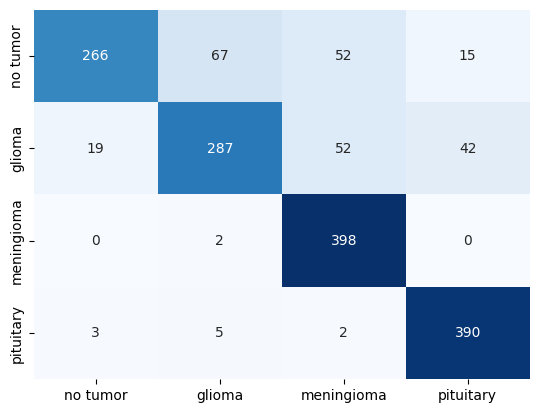

In [21]:
get_predictions(model_0, test_loader, device)

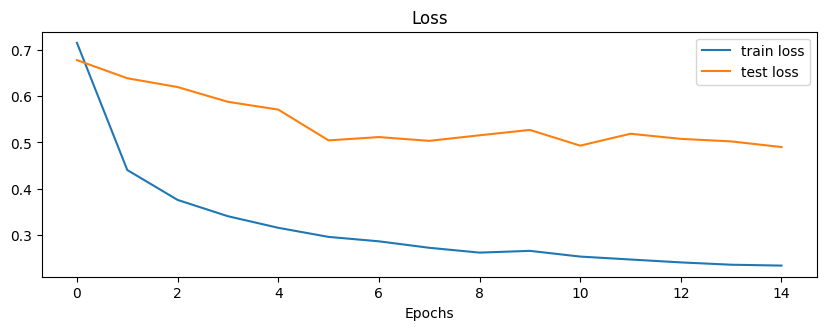

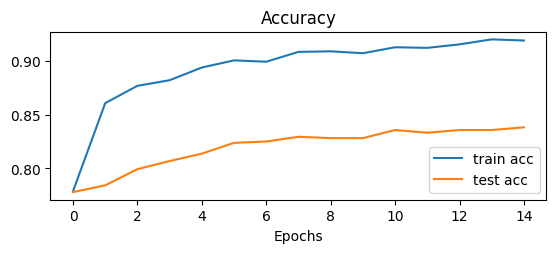

In [22]:
plot_loss_curves(model_0_results)

In [23]:
## MODEL VGG ANALYSIS

## MODEL VGG ANALYSIS

              precision    recall  f1-score   support

    no tumor       0.92      0.67      0.77       400
      glioma       0.80      0.72      0.75       400
  meningioma       0.79      0.99      0.88       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.83      1600
weighted avg       0.85      0.84      0.83      1600



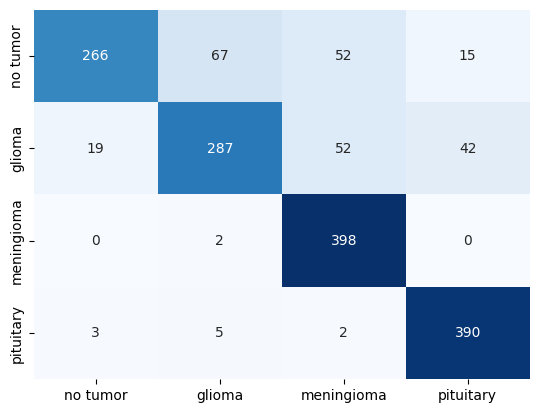

In [24]:
get_predictions(model_1, test_loader, device)

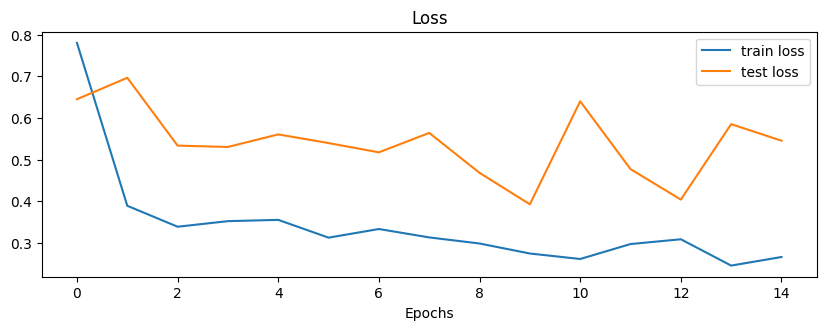

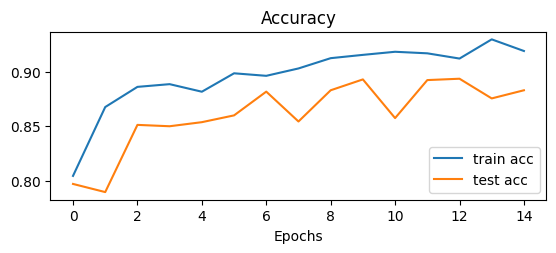

In [25]:
plot_loss_curves(model_1_results)

## Efficient Model Analysis

              precision    recall  f1-score   support

    no tumor       0.92      0.67      0.77       400
      glioma       0.80      0.72      0.75       400
  meningioma       0.79      0.99      0.88       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.83      1600
weighted avg       0.85      0.84      0.83      1600



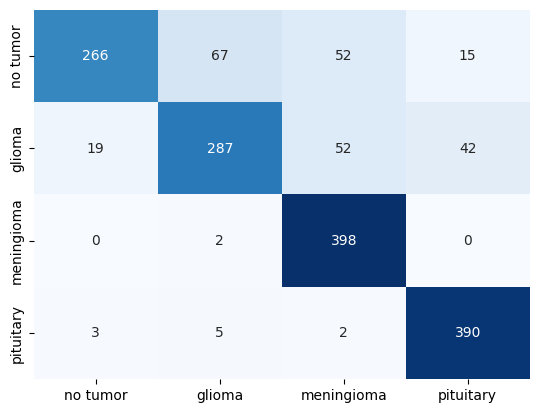

In [26]:
get_predictions(model_2, test_loader, device)

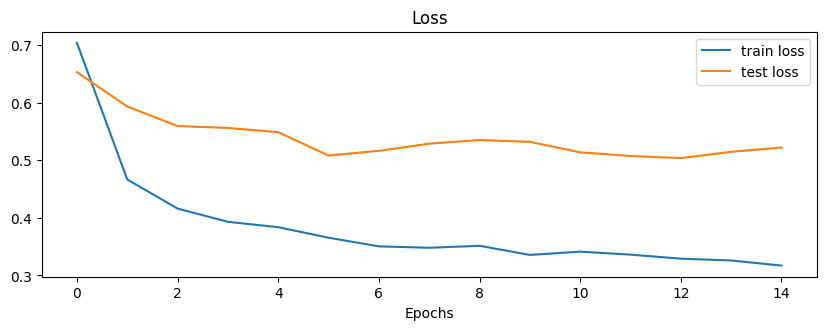

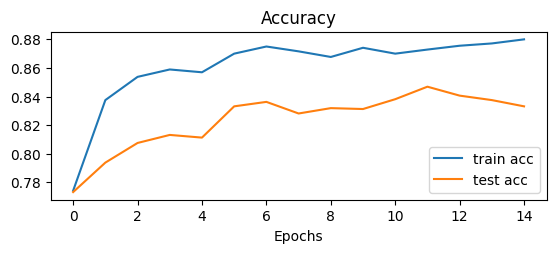

In [27]:
plot_loss_curves(model_2_results)

In [28]:
from torch import nn

model_3 = models.densenet121(weights = "DEFAULT")

for param in model_3.parameters(): param.requires_grad = False

model_3.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1024, out_features=4, bias=True)
    )

model_3 = model_3.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 230MB/s]


In [29]:
model_3_results = train(
    model=model_3,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,
    device=device
)

Epoch: 0 | Train loss: 0.7150 | Train acc: 0.7484 | Test loss: 0.6829 | Test acc: 0.7512
Epoch: 2 | Train loss: 0.3891 | Train acc: 0.8634 | Test loss: 0.6677 | Test acc: 0.7850
Epoch: 4 | Train loss: 0.3522 | Train acc: 0.8711 | Test loss: 0.5799 | Test acc: 0.8156
Epoch: 6 | Train loss: 0.3290 | Train acc: 0.8764 | Test loss: 0.5773 | Test acc: 0.8237
Epoch: 8 | Train loss: 0.2953 | Train acc: 0.8938 | Test loss: 0.5351 | Test acc: 0.8325
Epoch: 10 | Train loss: 0.2925 | Train acc: 0.8914 | Test loss: 0.5597 | Test acc: 0.8337
Epoch: 12 | Train loss: 0.2937 | Train acc: 0.8939 | Test loss: 0.5289 | Test acc: 0.8419
Epoch: 14 | Train loss: 0.2802 | Train acc: 0.8961 | Test loss: 0.5929 | Test acc: 0.8363


              precision    recall  f1-score   support

    no tumor       0.92      0.67      0.77       400
      glioma       0.80      0.72      0.75       400
  meningioma       0.79      0.99      0.88       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.83      1600
weighted avg       0.85      0.84      0.83      1600



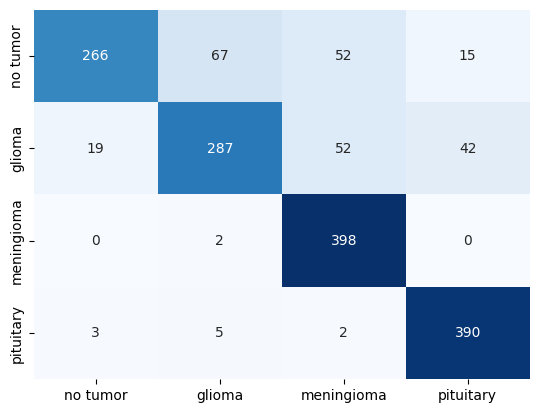

In [30]:
get_predictions(model_3, test_loader, device)

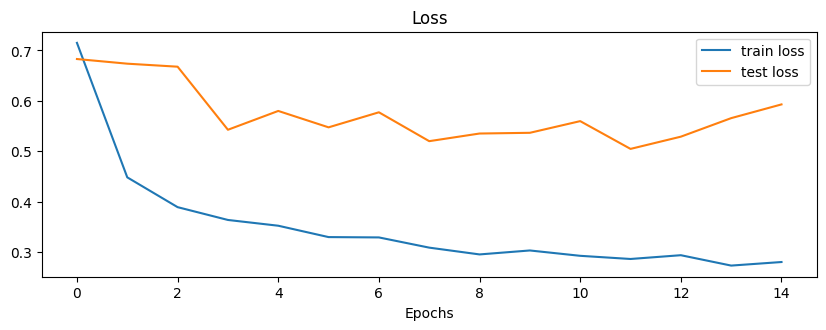

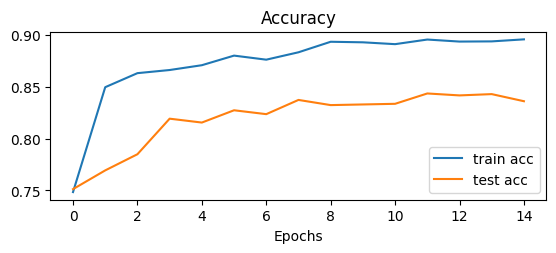

In [31]:
plot_loss_curves(model_3_results)

## Saving the models that i build

In [32]:
torch.save(model_0.state_dict(), "brain_tumor_resnet50.pth")
torch.save(model_1.state_dict(), "brain_tumor_vgg16.pth")
torch.save(model_2.state_dict(), "brain_tumor_efficientnet.pth")
torch.save(model_3.state_dict(), "brain_tumor_densenet.pth")